# ==========================================================
# Breast Cancer Survival Prediction using Apache Spark
# Notebook 06: Model Interpretation & Explainability
# ==========================================================

"""
Objective
---------
1. Load the best-performing classification model.
2. Analyze feature importance.
3. Investigate misclassified samples.
4. Interpret prediction results from a clinical perspective.
5. Identify model limitations.
6. Propose future improvements.
7. Summarize the overall findings of the study.

Mục tiêu
---------
1. Nạp mô hình phân loại tốt nhất.
2. Phân tích mức độ quan trọng của các đặc trưng.
3. Phân tích các trường hợp dự đoán sai.
4. Diễn giải kết quả dưới góc độ lâm sàng.
5. Xác định các hạn chế của mô hình.
6. Đề xuất hướng cải tiến trong tương lai.
7. Tổng kết các kết quả đạt được của nghiên cứu.
"""

In [1]:
# 1. Import Libraries | Khai báo thư viện

print("\n" + "="*60)
print("1. IMPORT LIBRARIES")
print("="*60)

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel
from pyspark.sql.functions import abs
from pyspark.sql.functions import col, avg, count


from pyspark.ml.classification import (
    LogisticRegressionModel,
    DecisionTreeClassificationModel,
    RandomForestClassificationModel,
    GBTClassificationModel
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Visualization Style Configuration

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    
from src.data.loader import create_spark_session
print("Libraries imported successfully.")


1. IMPORT LIBRARIES
Libraries imported successfully.


In [2]:
# 2. Create Spark Session | Khởi tạo Spark Session

print("\n"+"="*60)
print("2. CREATE SPARK SESSION")
print("="*60)

spark = create_spark_session("SEER Breast Cancer Model Interpretation")
print("Spark Session created successfully.")


2. CREATE SPARK SESSION
Spark Session created successfully.


In [3]:
# 3. Define Project Paths | Định nghĩa đường dẫn dự án

print("\n" + "=" * 60)
print("3. DEFINE PROJECT PATHS")
print("=" * 60)

MODEL_PATH = "../models/trained_models"

BEST_MODEL_PATH = "../models/best_model.txt"

DATA_PATH = "../data/processed/test_dataset.parquet"

REPORT_PATH = "../reports"

TABLE_PATH = os.path.join(
    REPORT_PATH,
    "tables"
)

FIGURE_PATH = os.path.join(
    REPORT_PATH,
    "figures"
)

RESULT_PATH = "../results"

os.makedirs(TABLE_PATH, exist_ok=True)
os.makedirs(FIGURE_PATH, exist_ok=True)
os.makedirs(RESULT_PATH, exist_ok=True)

print("Project paths initialized successfully.")


3. DEFINE PROJECT PATHS
Project paths initialized successfully.


In [4]:
# 4. Load Best Model Name | Đọc tên mô hình tốt nhất

print("\n" + "="*60)
print("4. LOAD BEST MODEL NAME")
print("="*60)

with open(BEST_MODEL_PATH, "r") as f:
    best_model_name = f.read().strip()

print(f"Selected Model : {best_model_name}")


4. LOAD BEST MODEL NAME
Selected Model : GBT Classifier


In [5]:
# 5. Load Feature Metadata | Nạp Metadata đặc trưng

print("\n" + "="*60)
print("5. LOAD FEATURE METADATA")
print("="*60)

DATA_PATH = "../data/processed/test_dataset.parquet"
test_df = spark.read.parquet(DATA_PATH)

if "weight" not in test_df.columns:
    test_df = test_df.withColumn("weight",F.lit(1.0))

print(f"Testing dataset loaded: {test_df.count():,} rows")


5. LOAD FEATURE METADATA
Testing dataset loaded: 90,756 rows


In [6]:

print("\n" + "="*60)
print("6. LOAD BEST MODEL")
print("="*60)

def spark_local_path(path):
       path = os.path.abspath(path)
       return "file:///" + path.replace("\\", "/")

model_mapping = {
    "Logistic Regression": LogisticRegressionModel,
    "Decision Tree": DecisionTreeClassificationModel,
    "Random Forest": RandomForestClassificationModel,
    "GBT Classifier": GBTClassificationModel
}

model_file = (best_model_name.lower().replace(" ", "_")+ "_model")

model_path = os.path.join(MODEL_PATH,model_file)
best_model = model_mapping[best_model_name].load(spark_local_path(model_path))

print("Best model loaded successfully.")


6. LOAD BEST MODEL
Best model loaded successfully.


In [7]:
# 7. Load Preprocessing Pipeline | Nạp Pipeline tiền xử lý

print("\n" + "=" * 60)
print("7. LOAD PREPROCESSING PIPELINE")
print("=" * 60)

if best_model_name == "Logistic Regression":
    pipeline_name = "logistic_regression_pipeline"
else:
    pipeline_name = "tree_models_pipeline"

pipeline_path = os.path.join(MODEL_PATH,pipeline_name)
pipeline = PipelineModel.load(spark_local_path(pipeline_path))

print(f"Pipeline Loaded : {pipeline_name}")


7. LOAD PREPROCESSING PIPELINE
Pipeline Loaded : tree_models_pipeline


In [8]:
# 8. Load Test Dataset | Nạp tập dữ liệu kiểm thử

print("\n" + "=" * 60)
print("8. LOAD TEST DATASET")
print("=" * 60)

test_df = spark.read.parquet(DATA_PATH)

if "weight" not in test_df.columns:test_df = test_df.withColumn("weight",F.lit(1.0))

print(f"Testing Rows : {test_df.count():,}")
print("Test dataset loaded successfully.")


8. LOAD TEST DATASET
Testing Rows : 90,756
Test dataset loaded successfully.


In [9]:
# 9. Dataset Overview | Tổng quan dữ liệu

print("\n" + "=" * 60)
print("9. DATASET OVERVIEW")
print("=" * 60)

processed_test = pipeline.transform(test_df)

predictions = best_model.transform(processed_test)

print("Prediction generated successfully.")

print(f"Best Model      : {best_model_name}")
print(f"Testing Rows    : {predictions.count():,}")
print(f"Total Columns   : {len(predictions.columns)}")

print("\nLabel Distribution")

(
    predictions
    .groupBy("label")
    .count()
    .orderBy("label")
    .show()
)

print("""
Label Mapping
0 -> Alive
1 -> Dead
""")


9. DATASET OVERVIEW
Prediction generated successfully.
Best Model      : GBT Classifier
Testing Rows    : 90,756
Total Columns   : 50

Label Distribution
+-----+-----+
|label|count|
+-----+-----+
|    0|57174|
|    1|33582|
+-----+-----+


Label Mapping
0 -> Alive
1 -> Dead



In [10]:
# 10. FEATURE IMPORTANCE ANALYSIS

print("\n" + "=" * 60)
print("10. FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Extract feature names from Spark metadata

metadata = predictions.schema["features"].metadata
feature_names = []

if "ml_attr" in metadata:
    attrs = metadata["ml_attr"]["attrs"]
    for attr_type in attrs:
        for item in attrs[attr_type]:
            feature_names.append(item["name"])

print(f"Total transformed features: {len(feature_names)}")

# Extract feature importance

if best_model_name == "Logistic Regression":
    print("Model Type : Logistic Regression")
    print("Using absolute coefficient values.")
    values = best_model.coefficients.toArray()
    contribution_name = "Coefficient"

else:
    print(f"Model Type : {best_model_name}")
    print("Using tree-based feature importance.")
    values = best_model.featureImportances.toArray()
    contribution_name = "Importance"

# Prevent feature mismatch

if len(feature_names) != len(values):
    print("WARNING : Feature size mismatch detected.")
    min_size = min(len(feature_names),len(values))
    feature_names = feature_names[:min_size]
    values = values[:min_size]

# Create DataFrame

feature_df = pd.DataFrame({"Feature": feature_names,contribution_name: values})
feature_df["Absolute_Impact"] = (feature_df[contribution_name].abs())

feature_df = (feature_df.sort_values("Absolute_Impact",ascending=False))

print(feature_df.head(20))


10. FEATURE IMPORTANCE ANALYSIS
Total transformed features: 24
Model Type : GBT Classifier
Using tree-based feature importance.
                               Feature  Importance  Absolute_Impact
19                   Age_Group_indexed    0.249271         0.249271
7               Marital_Status_indexed    0.137572         0.137572
18                Chemotherapy_indexed    0.108804         0.108804
2              Regional_Nodes_Examined    0.089623         0.089623
1                           Tumor_Size    0.065694         0.065694
21              Hormone_Status_indexed    0.062307         0.062307
4                           Node_Ratio    0.044983         0.044983
17                   Radiation_indexed    0.038441         0.038441
16  Surgery_Radiation_Sequence_indexed    0.036390         0.036390
11                      AJCC_M_indexed    0.032347         0.032347
3              Regional_Nodes_Positive    0.032184         0.032184
23        Surgery_Primary_Site_indexed    0.025359     

In [11]:
# 11. Rank Top Important Features | Xếp hạng đặc trưng quan trọng

print("\n" + "=" * 60)
print("11. RANK TOP IMPORTANT FEATURES")
print("=" * 60)

top20_features = feature_df.head(20)

print("Top 20 Most Important Features")
print("-" * 60)

display(top20_features)

top20_features.to_csv(os.path.join(TABLE_PATH,"feature_importance.csv"),index=False)

print("\nFeature importance table saved successfully.")


11. RANK TOP IMPORTANT FEATURES
Top 20 Most Important Features
------------------------------------------------------------


,Feature,Importance,Absolute_Impact
19,Age_Group_indexed,0.249271,0.249271
7,Marital_Status_indexed,0.137572,0.137572
18,Chemotherapy_indexed,0.108804,0.108804
2,Regional_Nodes_Examined,0.089623,0.089623
1,Tumor_Size,0.065694,0.065694
21,Hormone_Status_indexed,0.062307,0.062307
4,Node_Ratio,0.044983,0.044983
17,Radiation_indexed,0.038441,0.038441
16,Surgery_Radiation_Sequence_indexed,0.036390,0.036390
11,AJCC_M_indexed,0.032347,0.032347



Feature importance table saved successfully.



12. FEATURE IMPORTANCE VISUALIZATION


C:\Users\HOANG YEN\AppData\Local\Temp\ipykernel_15404\1880002201.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=top_features, x="Absolute_Impact", y="Feature", palette="viridis")


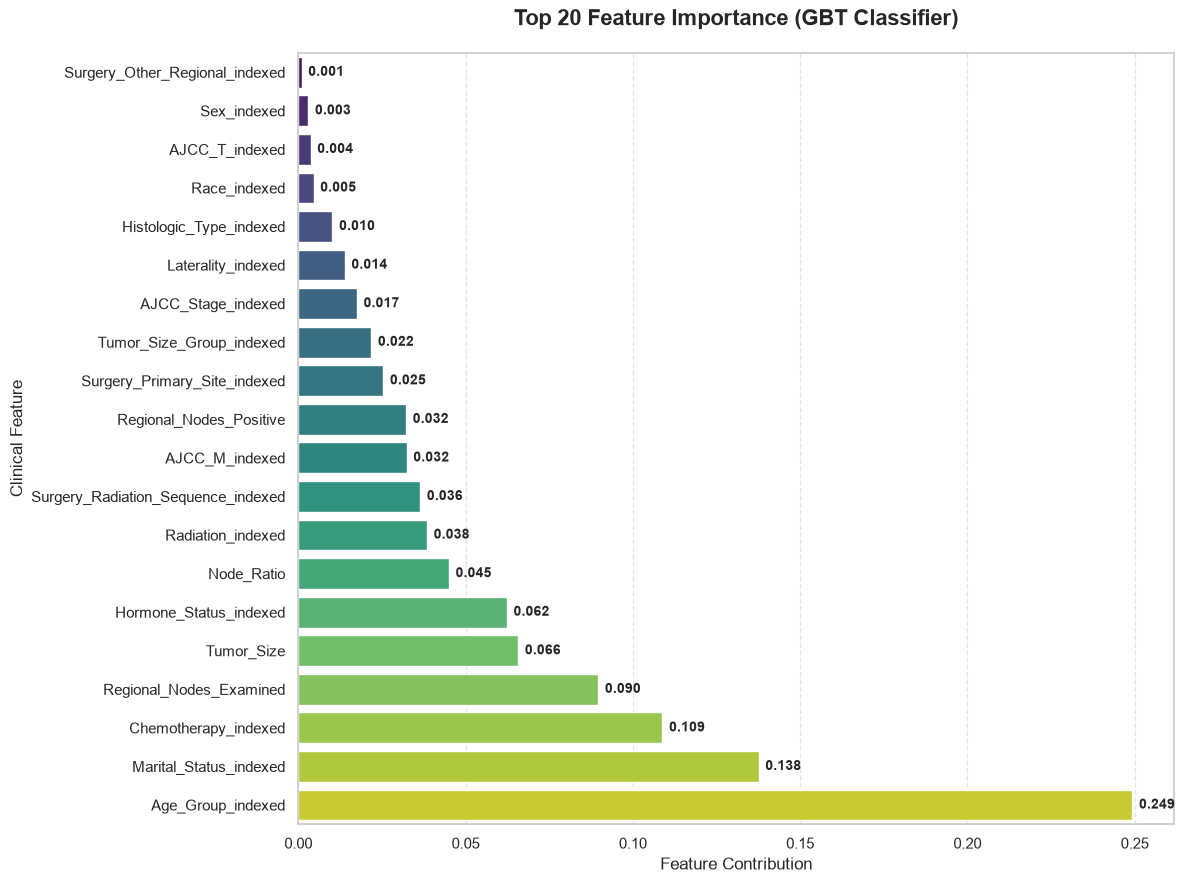

In [12]:
# 12. Feature Importance Visualization | Trực quan hóa độ quan trọng của đặc trưng

print("\n" + "=" * 60)
print("12. FEATURE IMPORTANCE VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(12, 9))
top_features = top20_features.sort_values("Absolute_Impact", ascending=True)

bars = sns.barplot(data=top_features, x="Absolute_Impact", y="Feature", palette="viridis")

for bar in bars.patches:
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.3f}", va="center", fontsize=10, fontweight="bold")

plt.title(f"Top 20 Feature Importance ({best_model_name})", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Feature Contribution", fontsize=12)
plt.ylabel("Clinical Feature", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/top20_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# 13. Analyze Misclassified Samples | Phân tích các mẫu dự đoán sai

print("\n" + "=" * 60)
print("13. ANALYZE MISCLASSIFIED SAMPLES")
print("=" * 60)

misclassified = predictions.filter(F.col("label") != F.col("prediction"))
misclassified_count = misclassified.count()

print(f"Total Misclassified Samples : {misclassified_count:,}")

misclassified.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

misclassified.write \
    .mode("overwrite") \
    .parquet("../results/misclassified_samples.parquet")

print("Misclassified samples exported successfully.")


13. ANALYZE MISCLASSIFIED SAMPLES
Total Misclassified Samples : 19,364
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |0.0       |[0.7909756345820623,0.20902436541793767]|
|1    |0.0       |[0.8138621504493725,0.1861378495506275] |
|1    |0.0       |[0.9134534534087325,0.08654654659126748]|
|1    |0.0       |[0.6953529275968211,0.3046470724031789] |
|1    |0.0       |[0.7032617938270352,0.29673820617296476]|
|0    |1.0       |[0.36640782391353904,0.6335921760864609]|
|1    |0.0       |[0.7694920276482888,0.23050797235171117]|
|1    |0.0       |[0.7309425179226209,0.2690574820773791] |
|0    |1.0       |[0.3484109077412803,0.6515890922587197] |
|0    |1.0       |[0.47784011621568956,0.5221598837843104]|
+-----+----------+----------------------------------------+
only showing top 10 rows

Misclassified samples exported successfully.


In [14]:
# 14. False Positive Analysis | Phân tích False Positive

print("\n" + "=" * 60)
print("14. FALSE POSITIVE ANALYSIS")
print("=" * 60)

false_positive = predictions.filter(
    (F.col("label") == 0) &
    (F.col("prediction") == 1)
)

fp_count = false_positive.count()

print(f"False Positive Samples : {fp_count:,}")
print()

print("Preview")
false_positive.select(
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

false_positive.write \
    .mode("overwrite") \
    .parquet("../results/false_positive_samples.parquet")

print("False Positive samples exported.")


14. FALSE POSITIVE ANALYSIS
False Positive Samples : 10,332

Preview
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |1.0       |[0.36640782391353904,0.6335921760864609]|
|0    |1.0       |[0.3484109077412803,0.6515890922587197] |
|0    |1.0       |[0.47784011621568956,0.5221598837843104]|
|0    |1.0       |[0.32888055225025464,0.6711194477497453]|
|0    |1.0       |[0.38576515552982904,0.614234844470171] |
|0    |1.0       |[0.31095743895408373,0.6890425610459163]|
|0    |1.0       |[0.3842665109079062,0.6157334890920938] |
|0    |1.0       |[0.3744814946357247,0.6255185053642753] |
|0    |1.0       |[0.05121638999916334,0.9487836100008367]|
|0    |1.0       |[0.3965495997314765,0.6034504002685235] |
+-----+----------+----------------------------------------+
only showing top 10 rows

False Positive samples exported.


In [15]:
# 15. False Negative Analysis | Phân tích False Negative

print("\n" + "=" * 60)
print("15. FALSE NEGATIVE ANALYSIS")
print("=" * 60)

false_negative = predictions.filter(
    (F.col("label") == 1) &
    (F.col("prediction") == 0)
)

fn_count = false_negative.count()

print(f"False Negative Samples : {fn_count:,}")
print()
print("Preview")

false_negative.select("label","prediction","probability").show(10, truncate=False)

false_negative.write \
    .mode("overwrite") \
    .parquet("../results/false_negative_samples.parquet")

print("False Negative samples exported.")


15. FALSE NEGATIVE ANALYSIS
False Negative Samples : 9,032

Preview
+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1    |0.0       |[0.7909756345820623,0.20902436541793767]|
|1    |0.0       |[0.8138621504493725,0.1861378495506275] |
|1    |0.0       |[0.9134534534087325,0.08654654659126748]|
|1    |0.0       |[0.6953529275968211,0.3046470724031789] |
|1    |0.0       |[0.7032617938270352,0.29673820617296476]|
|1    |0.0       |[0.7694920276482888,0.23050797235171117]|
|1    |0.0       |[0.7309425179226209,0.2690574820773791] |
|1    |0.0       |[0.593411794917899,0.40658820508210103] |
|1    |0.0       |[0.7220541572780051,0.27794584272199485]|
|1    |0.0       |[0.5538766137418795,0.44612338625812054]|
+-----+----------+----------------------------------------+
only showing top 10 rows

False Negative samples exported.


In [16]:
# 16. Error Analysis Summary | Tổng hợp các loại lỗi

print("\n" + "=" * 60)
print("16. ERROR ANALYSIS SUMMARY")
print("=" * 60)

TP = predictions.filter(
    (F.col("label") == 1) &
    (F.col("prediction") == 1)
).count()

TN = predictions.filter(
    (F.col("label") == 0) &
    (F.col("prediction") == 0)
).count()

FP = predictions.filter(
    (F.col("label") == 0) &
    (F.col("prediction") == 1)
).count()

FN = predictions.filter(
    (F.col("label") == 1) &
    (F.col("prediction") == 0)
).count()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
specificity = TN / (TN + FP)
f1 = 2 * precision * recall / (precision + recall)

fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print(f"True Positive        : {TP:,}")
print(f"True Negative        : {TN:,}")
print(f"False Positive       : {FP:,}")
print(f"False Negative       : {FN:,}")
print()

print(f"Accuracy             : {accuracy:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall (Sensitivity) : {recall:.4f}")
print(f"Specificity          : {specificity:.4f}")
print(f"F1-score             : {f1:.4f}")
print()

print(f"False Positive Rate  : {fpr:.4f}")
print(f"False Negative Rate  : {fnr:.4f}")

error_summary = pd.DataFrame({
    "Metric": [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1-score",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        TP,
        TN,
        FP,
        FN,
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        fpr,
        fnr
    ]
})

display(error_summary)
error_summary.to_csv(os.path.join(TABLE_PATH, "error_analysis_summary.csv"),index=False)

print("Error summary exported successfully.")


16. ERROR ANALYSIS SUMMARY
True Positive        : 24,550
True Negative        : 46,842
False Positive       : 10,332
False Negative       : 9,032

Accuracy             : 0.7866
Precision            : 0.7038
Recall (Sensitivity) : 0.7310
Specificity          : 0.8193
F1-score             : 0.7172

False Positive Rate  : 0.1807
False Negative Rate  : 0.2690


,Metric,Value
0,True Positive,24550.000000
1,True Negative,46842.000000
2,False Positive,10332.000000
3,False Negative,9032.000000
4,Accuracy,0.786637
5,Precision,0.703801
6,Recall,0.731046
7,Specificity,0.819288
8,F1-score,0.717165
9,False Positive Rate,0.180712


Error summary exported successfully.


In [17]:
# 17. Error Analysis by Feature | Phân tích lỗi theo đặc trưng

print("\n" + "=" * 60)
print("17. ERROR ANALYSIS BY FEATURE")
print("=" * 60) 

# Create Prediction Groups
prediction_df = predictions

error_analysis_df = prediction_df.withColumn(
    "Prediction_Group",
    F.when((col("label") == 1) & (col("prediction") == 1), "True Positive")
     .when((col("label") == 1) & (col("prediction") == 0), "False Negative")
     .when((col("label") == 0) & (col("prediction") == 1), "False Positive")
     .otherwise("True Negative")
)

# Sửa lại tên cột đúng: Prediction_Group (có chữ 'c')
error_analysis_df.groupBy("Prediction_Group").count().show()

# Numerical Feature Comparison


numeric_error_features = [
    "Age",
    "Tumor_Size",
    "Regional_Nodes_Examined",
    "Regional_Nodes_Positive",
    "Node_Ratio"
]

print("\nFeature Statistics by Prediction Group")
print("-" * 60)

for feature in numeric_error_features:
    if feature in error_analysis_df.columns:
        print("\nFeature:", feature)
        error_analysis_df.groupBy("Prediction_Group").agg(
            count(feature).alias("Count"),
            avg(feature).alias("Average")
        ).show()


17. ERROR ANALYSIS BY FEATURE
+----------------+-----+
|Prediction_Group|count|
+----------------+-----+
|  False Negative| 9032|
|  False Positive|10332|
|   True Positive|24550|
|   True Negative|46842|
+----------------+-----+


Feature Statistics by Prediction Group
------------------------------------------------------------

Feature: Age
+----------------+-----+-----------------+
|Prediction_Group|Count|          Average|
+----------------+-----+-----------------+
|  False Negative| 9032|54.66729406554473|
|  False Positive|10332|64.10327138985676|
|   True Positive|24550|69.98207739307536|
|   True Negative|46842|51.77436915588574|
+----------------+-----+-----------------+


Feature: Tumor_Size
+----------------+-----+------------------+
|Prediction_Group|Count|           Average|
+----------------+-----+------------------+
|  False Negative| 9032|21.844995571302036|
|  False Positive|10332|28.775067750677508|
|   True Positive|24550|31.746150712830957|
|   True Negative|46842

In [18]:
# 18. Define Feature Categories |  Tạo biến category_df
print("\n" + "=" * 60)
print("18. DEFINE FEATURE CATEGORIES")
print("=" * 60)

def categorize_feature(feature_name):
    """Phân loại tên đặc trưng vào các nhóm lâm sàng tương ứng."""
    name_lower = str(feature_name).lower()
    
    if any(k in name_lower for k in ["age", "race", "marital", "sex", "gender"]):
        return "Demographics"
    elif any(k in name_lower for k in ["tumor", "size", "grade", "stage", "t_stage", "ajcc"]):
        return "Tumor Characteristics"
    elif any(k in name_lower for k in ["node", "nodes", "n_stage", "exam"]):
        return "Nodal Status"
    elif any(k in name_lower for k in ["chemo", "radiation", "surgery", "therapy"]):
        return "Treatment"
    elif any(k in name_lower for k in ["estrogen", "progesterone", "er", "pr", "her2"]):
        return "Biomarkers"
    else:
        return "Other Clinical Factors"

# 1. Gán nhòm category cho từng feature
feature_df["Category"] = feature_df["Feature"].apply(categorize_feature)

# 2. Gom nhóm tính tổng độ quan trọng
category_df = (
    feature_df
    .groupby("Category")["Absolute_Impact"]
    .sum()
    .reset_index()
    .sort_values(by="Absolute_Impact", ascending=False)
)

print("\nCategory Feature Importance aggregated successfully:")
print(category_df)


18. DEFINE FEATURE CATEGORIES

Category Feature Importance aggregated successfully:
                 Category  Absolute_Impact
1            Demographics         0.412344
4               Treatment         0.209929
2            Nodal Status         0.166790
5   Tumor Characteristics         0.124620
3  Other Clinical Factors         0.072474
0              Biomarkers         0.013843



19. FEATURE CATEGORY IMPORTANCE


C:\Users\HOANG YEN\AppData\Local\Temp\ipykernel_15404\1777942415.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


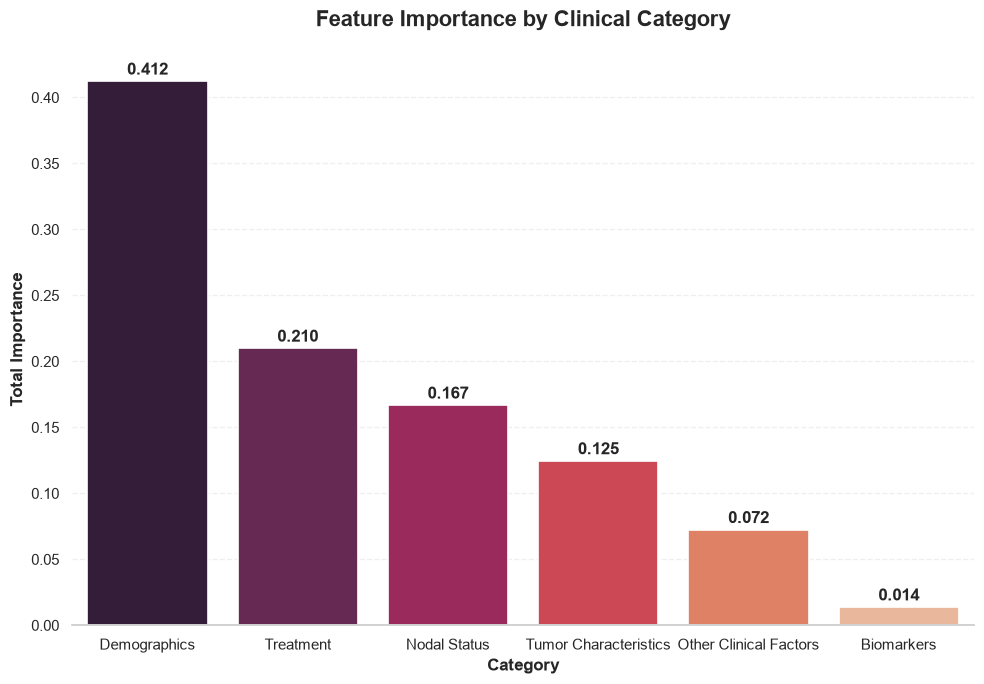

In [19]:
# 19. Feature Category Importance | Độ quan trọng theo danh mục đặc trưng

print("\n" + "=" * 60)
print("19. FEATURE CATEGORY IMPORTANCE")
print("=" * 60)

plt.figure(figsize=(10, 7))

category_df_sorted = category_df.sort_values("Absolute_Impact", ascending=False)
bars = sns.barplot(
    data=category_df_sorted, 
    x="Category", 
    y="Absolute_Impact", 
    palette="rocket",
    edgecolor="white",
    linewidth=1.2
)

for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + 0.005, 
        f"{bar.get_height():.3f}", 
        ha="center", 
        fontsize=12, 
        fontweight="bold"
    )

plt.title("Feature Importance by Clinical Category", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Category", fontsize=12, fontweight="bold")
plt.ylabel("Total Importance", fontsize=12, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine(left=True)

plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/feature_category_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# Kiểm tra danh sách tất cả các cột đang có trong prediction_df
print("Các cột hiện có trong DataFrame:")
print(prediction_df.columns)

Các cột hiện có trong DataFrame:
['Age', 'Sex', 'Race', 'Marital_Status', 'Tumor_Size', 'Grade', 'AJCC_T', 'AJCC_N', 'Regional_Nodes_Examined', 'Regional_Nodes_Positive', 'Sequence_Number', 'Histologic_Type', 'Laterality', 'Diagnostic_Confirmation', 'AJCC_M', 'Surgery_Primary_Site', 'Surgery_Other_Regional', 'Surgery_Radiation_Sequence', 'Radiation', 'Chemotherapy', 'AJCC_Stage', 'label', 'Age_Group', 'Tumor_Size_Group', 'Node_Ratio', 'Hormone_Status', 'weight', 'Sex_indexed', 'Race_indexed', 'Marital_Status_indexed', 'Grade_indexed', 'AJCC_T_indexed', 'AJCC_N_indexed', 'AJCC_M_indexed', 'AJCC_Stage_indexed', 'Laterality_indexed', 'Diagnostic_Confirmation_indexed', 'Surgery_Other_Regional_indexed', 'Surgery_Radiation_Sequence_indexed', 'Radiation_indexed', 'Chemotherapy_indexed', 'Age_Group_indexed', 'Tumor_Size_Group_indexed', 'Hormone_Status_indexed', 'Histologic_Type_indexed', 'Surgery_Primary_Site_indexed', 'features', 'rawPrediction', 'probability', 'prediction']


In [21]:
# 20. Misclassified Case Study | Phân tích trường hợp dự đoán sai

print("\n" + "=" * 60)
print("20. MISCLASSIFIED CASE STUDY")
print("=" * 60)

prediction_df = predictions
display_cols = [
    "Age",
    "Tumor_Size",
    "AJCC_Stage",
    "Regional_Nodes_Positive",
    "Node_Ratio",
    "Hormone_Status",
    "Chemotherapy",
    "Radiation",
    "probability"
]

# Lọc an toàn các cột có trong DataFrame
avail_cols = [c for c in display_cols if c in prediction_df.columns]

# 1. FALSE NEGATIVE (Thực tế: Dead [1] | Mô hình đoán: Alive [0])

print("\n[FALSE NEGATIVE CASES] - Top 20 mẫu bị mô hình đánh giá rủi ro quá thấp")
print("-" * 75)

fn_df = prediction_df.filter((F.col("label") == 1) & (F.col("prediction") == 0))

fn_df.select(*avail_cols) \
     .orderBy(F.col("probability").desc()) \
     .show(20, truncate=False)

print("-> Thống kê tổng quan nhóm False Negative:")
fn_df.groupBy().agg(
    F.avg("Age").alias("Avg_Age"),
    F.avg("Tumor_Size").alias("Avg_Tumor_Size"),
    F.avg("Regional_Nodes_Positive").alias("Avg_Nodes_Pos"),
    F.avg("Node_Ratio").alias("Avg_Node_Ratio"),
    F.count("label").alias("Total_FN_Cases")
).show()

# 2. FALSE POSITIVE (Thực tế: Alive [0] | Mô hình đoán: Dead [1])

print("\n[FALSE POSITIVE CASES] - Top 20 mẫu bị mô hình đánh giá rủi ro quá cao")
print("-" * 75)

fp_df = prediction_df.filter((F.col("label") == 0) & (F.col("prediction") == 1))

fp_df.select(*avail_cols) \
     .orderBy(F.col("probability").asc()) \
     .show(20, truncate=False)

print("-> Thống kê tổng quan nhóm False Positive:")
fp_df.groupBy().agg(
    F.avg("Age").alias("Avg_Age"),
    F.avg("Tumor_Size").alias("Avg_Tumor_Size"),
    F.avg("Regional_Nodes_Positive").alias("Avg_Nodes_Pos"),
    F.avg("Node_Ratio").alias("Avg_Node_Ratio"),
    F.count("label").alias("Total_FP_Cases")
).show()


20. MISCLASSIFIED CASE STUDY

[FALSE NEGATIVE CASES] - Top 20 mẫu bị mô hình đánh giá rủi ro quá thấp
---------------------------------------------------------------------------
+----+----------+----------+-----------------------+----------+--------------+------------+-----------------------------------------------------+-----------------------------------------+
|Age |Tumor_Size|AJCC_Stage|Regional_Nodes_Positive|Node_Ratio|Hormone_Status|Chemotherapy|Radiation                                            |probability                              |
+----+----------+----------+-----------------------+----------+--------------+------------+-----------------------------------------------------+-----------------------------------------+
|40.0|5         |0         |0                      |0.0       |HR_Mixed      |No/Unknown  |None/Unknown                                         |[0.9509342140222706,0.04906578597772937] |
|40.0|7         |I         |0                      |0.0       |HR_Pos

In [22]:
# 21. Prediction Probability Analysis | Phân tích xác suất dự đoán

print("\n" + "=" * 60)
print("21. PREDICTION PROBABILITY ANALYSIS")
print("=" * 60)

# Used for ROC, PR Curve and Threshold Analysis

threshold_df = predictions.select("label","prediction","probability").toPandas()

# Extract probability of Dead class (label = 1)
threshold_df["dead_probability"] = (threshold_df["probability"].apply(lambda x: float(x[1])))

print(f"Total Samples : {len(threshold_df):,}")

display(threshold_df.head())
print("Prediction probability dataset created successfully.")


21. PREDICTION PROBABILITY ANALYSIS
Total Samples : 90,756


,label,prediction,probability,dead_probability
0,0,0.0,"[0.7827314353662786, 0.21726856463372135]",0.217269
1,0,0.0,"[0.530228908829619, 0.46977109117038096]",0.469771
2,1,0.0,"[0.7909756345820623, 0.20902436541793767]",0.209024
3,1,1.0,"[0.2789124868985308, 0.7210875131014691]",0.721088
4,0,0.0,"[0.5409310913695594, 0.4590689086304406]",0.459069


Prediction probability dataset created successfully.



22. ROC CURVE ANALYSIS


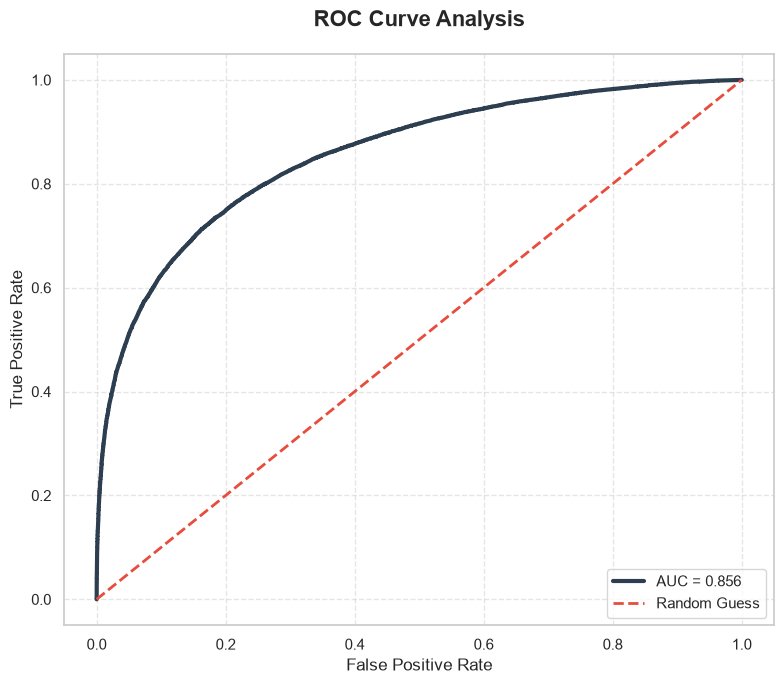

In [23]:
# 22. ROC Curve Analysis | Phân tích đường cong ROC

print("\n" + "=" * 60)
print("22. ROC CURVE ANALYSIS")
print("=" * 60)

from sklearn.metrics import roc_curve, auc

threshold_df["dead_probability"] = threshold_df["probability"].apply(lambda x: float(x[1]))
fpr, tpr, _ = roc_curve(threshold_df["label"], threshold_df["dead_probability"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color="#2c3e50", linewidth=3, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color="#e74c3c", linestyle="--", linewidth=2, label="Random Guess")

plt.title("ROC Curve Analysis", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


23. PRECISION-RECALL CURVE


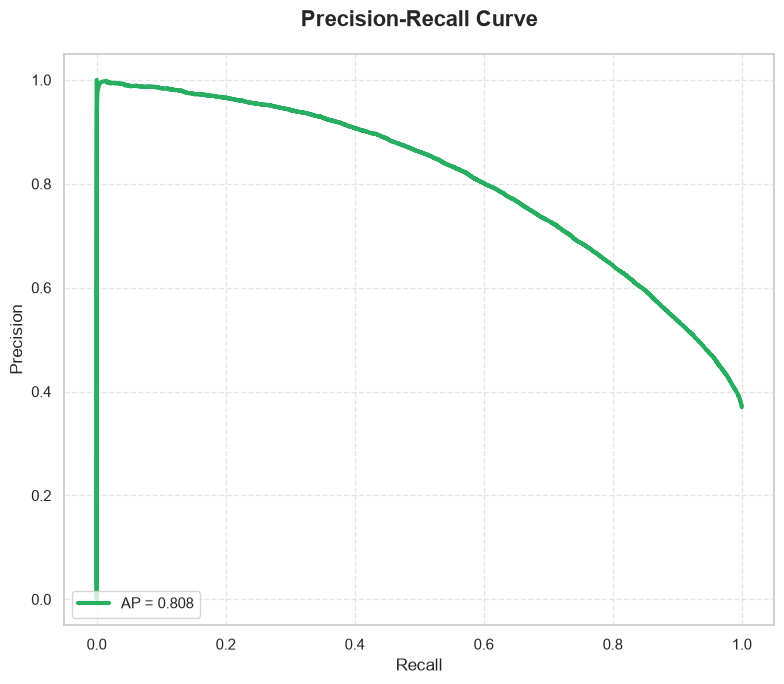

In [24]:
# 23. Precision-Recall Curve | Đường cong Precision-Recall

print("\n" + "=" * 60)
print("23. PRECISION-RECALL CURVE")
print("=" * 60)

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(threshold_df["label"], threshold_df["dead_probability"])
ap = average_precision_score(threshold_df["label"], threshold_df["dead_probability"])

plt.figure(figsize=(8, 7))
plt.plot(recall, precision, color="#27ae60", linewidth=3, label=f"AP = {ap:.3f}")

plt.title("Precision-Recall Curve", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="lower left", fontsize=11)
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# 24. Threshold Tuning Analysis | Phân tích điều chỉnh ngưỡng

print("""
Threshold Tuning Analysis
=========================

The default threshold of 0.50 was further investigated.

In survival prediction problems, False Negative errors
are clinically important because high-risk patients
may be incorrectly classified as survivors.

Therefore, different decision thresholds were evaluated:

0.35
0.40
0.45
0.50

The objective is to analyze the trade-off between:

- Recall (Sensitivity)
- False Negative Rate
- Overall Accuracy

""")


Threshold Tuning Analysis

The default threshold of 0.50 was further investigated.

In survival prediction problems, False Negative errors
are clinically important because high-risk patients
may be incorrectly classified as survivors.

Therefore, different decision thresholds were evaluated:

0.35
0.40
0.45
0.50

The objective is to analyze the trade-off between:

- Recall (Sensitivity)
- False Negative Rate
- Overall Accuracy




In [26]:
# 25. Threshold Comparison | So sánh các ngưỡng

print("\n" + "=" * 60)
print("25. THRESHOLD COMPARISON")
print("=" * 60)

threshold_results = []
threshold_values = [0.35, 0.40, 0.45, 0.50]

for threshold in threshold_values:
    y_true = threshold_df["label"]
    y_pred = (threshold_df["dead_probability"] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "False Positive": fp,
        "False Negative": fn,
        "False Positive Rate": fp / (fp + tn) if (fp + tn) > 0 else 0,
        "False Negative Rate": fn / (fn + tp) if (fn + tp) > 0 else 0
    })

# Tạo DataFrame và định dạng hiển thị chuyên nghiệp
threshold_results_df = pd.DataFrame(threshold_results)

# Hiển thị bảng với style làm nổi bật giá trị
display(threshold_results_df.style
        .format({col: "{:.4f}" for col in threshold_results_df.columns if col not in ["Threshold", "False Positive", "False Negative"]})
        .background_gradient(cmap="Blues", subset=["Accuracy", "F1-score"])
        .set_properties(**{'text-align': 'center'}))

# Export results
threshold_results_df.to_csv(os.path.join(TABLE_PATH, "threshold_comparison.csv"), index=False)

print("\nThreshold comparison exported successfully to: " + TABLE_PATH + "/threshold_comparison.csv")


25. THRESHOLD COMPARISON


,Threshold,Accuracy,Precision,Recall,F1-score,Specificity,False Positive,False Negative,False Positive Rate,False Negative Rate
0,0.350000,0.7378,0.6051,0.8387,0.7030,0.6785,18379,5417,0.3215,0.1613
1,0.400000,0.7590,0.6384,0.8040,0.7117,0.7325,15292,6582,0.2675,0.1960
2,0.450000,0.7755,0.6721,0.7677,0.7167,0.7800,12579,7800,0.2200,0.2323
3,0.500000,0.7866,0.7038,0.7310,0.7172,0.8193,10332,9032,0.1807,0.2690



Threshold comparison exported successfully to: ../reports\tables/threshold_comparison.csv



26. THRESHOLD PERFORMANCE VISUALIZATION


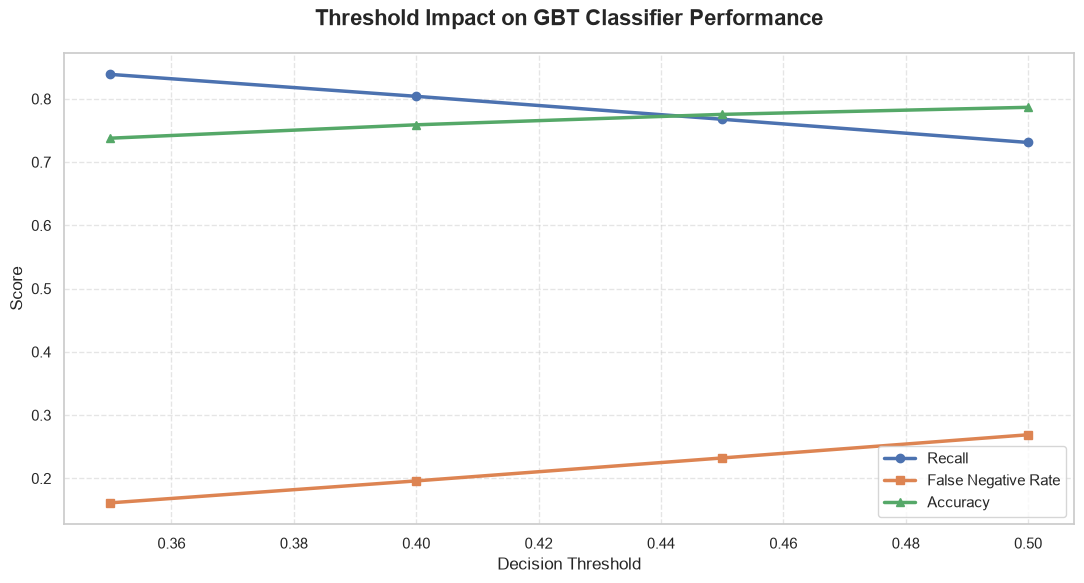

In [27]:
# 26. Threshold Performance Visualization | Trực quan hóa hiệu quả ngưỡng

print("\n" + "=" * 60)
print("26. THRESHOLD PERFORMANCE VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(11, 6))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", linewidth=2.5, label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["False Negative Rate"], marker="s", linewidth=2.5, label="False Negative Rate")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Accuracy"], marker="^", linewidth=2.5, label="Accuracy")

plt.title("Threshold Impact on GBT Classifier Performance", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Decision Threshold", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(fontsize=11)
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURE_PATH}/threshold_analysis.png", dpi=300, bbox_inches="tight")
plt.show()


27. CONFUSION MATRIX


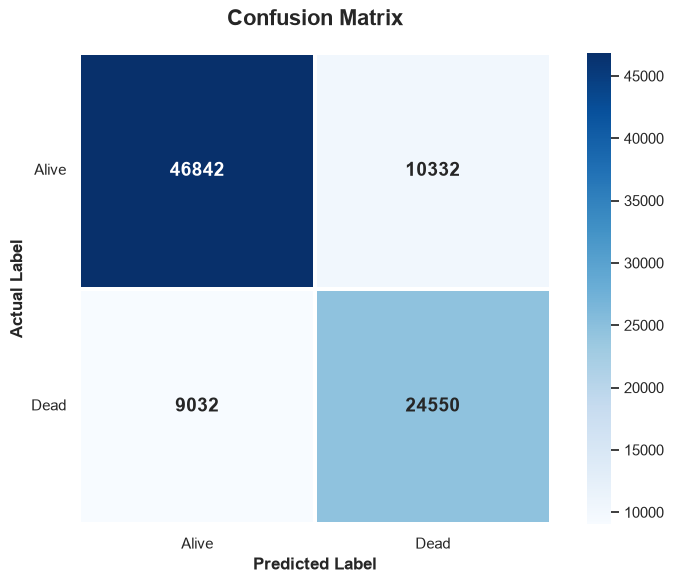

In [28]:
# 27. Confusion Matrix | Ma trận nhầm lẫn

print("\n" + "=" * 60)
print("27. CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(
    predictions.select("label").toPandas(),
    predictions.select("prediction").toPandas()
)

cm_df = pd.DataFrame(cm, index=["Alive", "Dead"], columns=["Alive", "Dead"])

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_df, 
    annot=True, 
    fmt="d", 
    cmap="Blues",       
    cbar=True,       
    linewidths=1.5, 
    linecolor="white",
    annot_kws={"fontsize": 14, "fontweight": "bold"},
    square=True
)

plt.title("Confusion Matrix", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("Actual Label", fontsize=12, fontweight="bold")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()


28. PREDICTION CONFIDENCE ANALYSIS


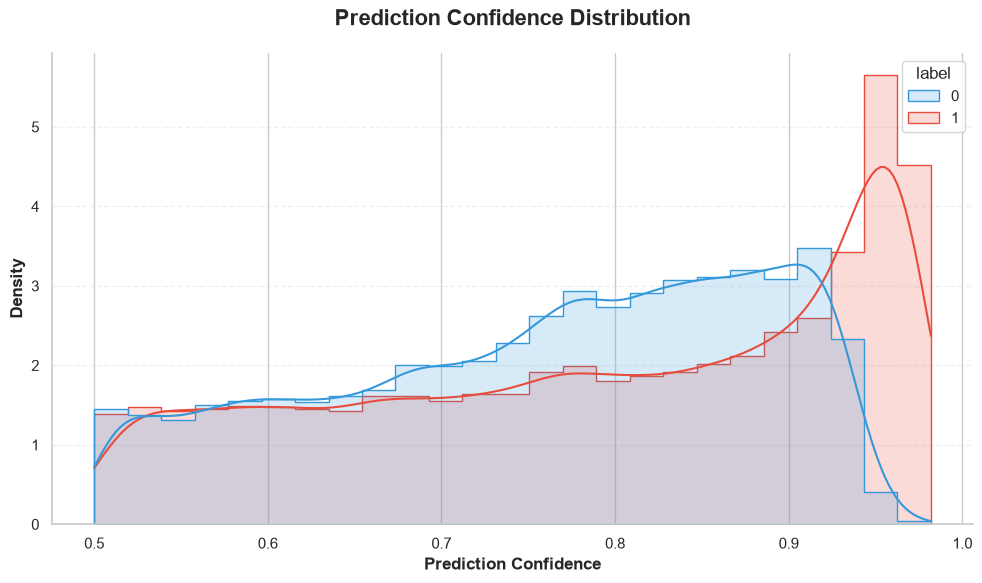

,label,prediction,confidence
count,90756.000000,90756.000000,90756.000000
mean,0.370025,0.384349,0.771170
std,0.482814,0.486444,0.132172
min,0.000000,0.000000,0.500007
25%,0.000000,0.000000,0.667887
50%,0.000000,0.000000,0.788303
75%,1.000000,1.000000,0.884436
max,1.000000,1.000000,0.981897


In [29]:
# 28. Prediction Confidence Analysis | Phân tích độ tin cậy dự đoán

print("\n" + "=" * 60)
print("28. PREDICTION CONFIDENCE ANALYSIS")
print("=" * 60)

confidence_df = predictions.select("label", "prediction", "probability").toPandas()
confidence_df["confidence"] = confidence_df["probability"].apply(lambda x: float(max(x)))

plt.figure(figsize=(10, 6))

sns.histplot(
    data=confidence_df, 
    x="confidence", 
    hue="label", 
    bins=25, 
    kde=True, 
    stat="density", 
    common_norm=False,
    palette=["#3498db", "#e74c3c"],
    element="step",
    alpha=0.2
)

plt.title("Prediction Confidence Distribution", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Prediction Confidence", fontsize=12, fontweight="bold")
plt.ylabel("Density", fontsize=12, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, "prediction_confidence.png"), dpi=300, bbox_inches="tight")
plt.show()

display(confidence_df.describe())

In [ ]:
# 29. Clinical Insight | Phân tích phát hiện từ mô hình

print("""
Clinical Insight
================

1. Feature Importance
Important clinical variables identified by the model
represent major factors associated with survival prediction.

2. Error Pattern Analysis
False Negative cases indicate patients with mortality risk
that was underestimated by the model.

3. Prediction Uncertainty
Incorrect predictions are mainly expected near the
decision boundary where prediction probability is uncertain.

4. Clinical Relevance
Tumor characteristics, lymph node involvement,
and patient demographic information provide important
signals for survival prediction.

5. Research Implication
Model interpretation helps identify potential limitations
and areas for future clinical data integration.

------------------------------------------------------------
Phân tích phát hiện từ mô hình
==============================

1. Mức độ quan trọng của đặc trưng
Các biến lâm sàng quan trọng phản ánh những yếu tố
ảnh hưởng lớn đến khả năng dự đoán sống còn.

2. Mẫu lỗi dự đoán
Các trường hợp False Negative đại diện cho nhóm bệnh nhân
có nguy cơ tử vong nhưng bị mô hình đánh giá thấp.

3. Độ không chắc chắn của dự đoán
Các dự đoán sai thường xuất hiện ở vùng xác suất gần
ngưỡng quyết định.


4. Ý nghĩa lâm sàng
Đặc điểm khối u, tình trạng hạch bạch huyết và
thông tin bệnh nhân là các yếu tố quan trọng trong
dự đoán kết quả sống còn.

5. Hướng nghiên cứu
Kết quả diễn giải mô hình giúp xác định hạn chế
và định hướng tích hợp thêm dữ liệu lâm sàng.

""")

In [ ]:
# 30. Clinical Interpretation | Diễn giải lâm sàng

print("""
Clinical Interpretation
=======================
1. Tumor Characteristics
Tumor-related variables such as tumor size and lymph node
involvement represent important clinical indicators associated
with breast cancer survival outcomes.

2. Patient Demographic Factors
Age at diagnosis provides additional information related to
patient survival patterns and risk differences among groups.

3. Model Error Interpretation
False Negative cases represent patients who were predicted
as survivors but experienced mortality.

These cases are clinically important because they indicate
potential underestimation of patient risk.

4. Prediction Confidence
Samples with prediction probability near the decision threshold
show higher uncertainty and contribute significantly to model errors.

5. Clinical Application Perspective
The model should be considered as a decision-support tool
rather than a replacement for clinical diagnosis.

Model predictions should be combined with professional
medical evaluation and additional clinical information.

------------------------------------------------------------
Diễn giải lâm sàng
===================

1. Đặc điểm khối u
Các đặc trưng liên quan đến khối u như kích thước u và
tình trạng hạch bạch huyết là những yếu tố quan trọng
ảnh hưởng đến kết quả sống còn của bệnh nhân ung thư vú.

2. Yếu tố nhân khẩu học
Tuổi tại thời điểm chẩn đoán cung cấp thêm thông tin
về sự khác biệt nguy cơ sống còn giữa các nhóm bệnh nhân.

3. Diễn giải lỗi dự đoán
Các trường hợp False Negative là những bệnh nhân được
mô hình dự đoán sống nhưng thực tế có kết quả tử vong.

Đây là nhóm quan trọng vì mô hình có thể đánh giá thấp
mức độ nguy cơ của bệnh nhân.

4. Độ tin cậy dự đoán
Các mẫu có xác suất dự đoán gần ngưỡng phân loại thường
có mức độ không chắc chắn cao hơn và dễ xảy ra lỗi.

5. Khả năng ứng dụng lâm sàng
Mô hình nên được xem như một công cụ hỗ trợ quyết định,
không thay thế cho quá trình chẩn đoán của bác sĩ.

Kết quả dự đoán cần được kết hợp với đánh giá chuyên môn
và các thông tin lâm sàng bổ sung.

""")


Clinical Interpretation
1. Tumor Characteristics
Tumor-related variables such as tumor size and lymph node
involvement represent important clinical indicators associated
with breast cancer survival outcomes.

2. Patient Demographic Factors
Age at diagnosis provides additional information related to
patient survival patterns and risk differences among groups.

3. Model Error Interpretation
False Negative cases represent patients who were predicted
as survivors but experienced mortality.

These cases are clinically important because they indicate
potential underestimation of patient risk.

4. Prediction Confidence
Samples with prediction probability near the decision threshold
show higher uncertainty and contribute significantly to model errors.

5. Clinical Application Perspective
The model should be considered as a decision-support tool
rather than a replacement for clinical diagnosis.

Model predictions should be combined with professional
medical evaluation and additional clinical i

In [ ]:
# 31. Model Limitations | Hạn chế mô hình

print("\n" + "=" * 60)
print("32. MODEL LIMITATIONS")
print("=" * 60)


limitations = [
    "The model may struggle with borderline probability cases.",
    "Rare histologic types may contain insufficient training samples.",
    "Some important clinical variables are unavailable or missing.",
    "Treatment-related information may not fully represent patient management.",
    "External validation on independent datasets is required."
]

print("Model Limitations")
print("-" * 60)

for i, item in enumerate(limitations, 1):
    print(f"{i}. {item}")


print("\nFuture Improvements")
print("-" * 60)

future_work = [
    "SHAP-based explainability",
    "Survival analysis models",
    "Integration of molecular biomarkers",
    "Comparison with advanced ML algorithms"
]


for item in future_work:
    print("-", item)


32. MODEL LIMITATIONS
Model Limitations
------------------------------------------------------------
1. The model may struggle with borderline probability cases.
2. Rare histologic types may contain insufficient training samples.
3. Some important clinical variables are unavailable or missing.
4. Treatment-related information may not fully represent patient management.
5. External validation on independent datasets is required.

Future Improvements
------------------------------------------------------------
- SHAP-based explainability
- Survival analysis models
- Integration of molecular biomarkers
- Comparison with advanced ML algorithms


In [ ]:
# 32. Model Interpretation Summary | Tổng kết

print("""

Model Interpretation Summary
============================

✓ Best-performing model successfully loaded.

✓ Clinical feature importance analyzed.

✓ Top influential variables identified.

✓ Misclassified samples investigated.

✓ False Positive and False Negative cases analyzed.

✓ Decision threshold sensitivity evaluated.

✓ Prediction confidence interpreted.

✓ Clinical implications discussed.

✓ Model limitations identified.

✓ Future research directions proposed.

Notebook 06 completed successfully.

------------------------------------------------------------

Tổng kết diễn giải mô hình
==========================

✓ Nạp thành công mô hình có hiệu suất tốt nhất.

✓ Phân tích mức độ quan trọng của các đặc trưng.

✓ Xác định các biến ảnh hưởng lớn nhất đến dự đoán.

✓ Phân tích các trường hợp dự đoán sai.

✓ Đánh giá False Positive và False Negative.

✓ Phân tích ảnh hưởng của việc điều chỉnh Threshold.

✓ Phân tích mức độ tin cậy của dự đoán.

✓ Diễn giải ý nghĩa lâm sàng của kết quả.

✓ Xác định các hạn chế của mô hình.

✓ Đề xuất các hướng nghiên cứu và cải tiến trong tương lai.

Notebook 06 hoàn thành thành công.

""")



Model Interpretation Summary

✓ Best-performing model successfully loaded.

✓ Clinical feature importance analyzed.

✓ Top influential variables identified.

✓ Misclassified samples investigated.

✓ False Positive and False Negative cases analyzed.

✓ Decision threshold sensitivity evaluated.

✓ Prediction confidence interpreted.

✓ Clinical implications discussed.

✓ Model limitations identified.

✓ Future research directions proposed.

Notebook 06 completed successfully.

------------------------------------------------------------

Tổng kết diễn giải mô hình

✓ Nạp thành công mô hình có hiệu suất tốt nhất.

✓ Phân tích mức độ quan trọng của các đặc trưng.

✓ Xác định các biến ảnh hưởng lớn nhất đến dự đoán.

✓ Phân tích các trường hợp dự đoán sai.

✓ Đánh giá False Positive và False Negative.

✓ Phân tích ảnh hưởng của việc điều chỉnh Threshold.

✓ Phân tích mức độ tin cậy của dự đoán.

✓ Diễn giải ý nghĩa lâm sàng của kết quả.

✓ Xác định các hạn chế của mô hình.

✓ Đề xuất các h

In [33]:
# 34. Notebook Completion | Hoàn thành Notebook

print("""
Notebook 06 completed successfully.

Generated reports:

✓ Feature importance analysis
✓ Feature category importance analysis
✓ Misclassification analysis
✓ False Positive / False Negative analysis
✓ ROC curve evaluation
✓ Precision-Recall curve evaluation
✓ Threshold sensitivity analysis
✓ Confusion matrix analysis
✓ Prediction confidence analysis
✓ Clinical risk analysis
✓ Model limitations identification
✓ Future improvement recommendations

All interpretation results have been exported
to the reports/ directory.

------------------------------------------------------------

Notebook 06 hoàn thành thành công.

Các kết quả đã được tạo:

✓ Phân tích mức độ quan trọng của đặc trưng
✓ Phân tích mức độ quan trọng theo nhóm lâm sàng
✓ Phân tích các trường hợp dự đoán sai
✓ Phân tích False Positive và False Negative
✓ Đánh giá đường cong ROC
✓ Đánh giá đường cong Precision-Recall
✓ Phân tích ảnh hưởng của Threshold
✓ Xây dựng ma trận nhầm lẫn
✓ Phân tích độ tin cậy của dự đoán
✓ Phân tích nguy cơ lâm sàng
✓ Xác định các hạn chế của mô hình
✓ Đề xuất các hướng cải tiến trong tương lai

Toàn bộ kết quả phân tích và biểu đồ đã được
xuất vào thư mục reports/.
""")


Notebook 06 completed successfully.

Generated reports:

✓ Feature importance analysis
✓ Feature category importance analysis
✓ Misclassification analysis
✓ False Positive / False Negative analysis
✓ ROC curve evaluation
✓ Precision-Recall curve evaluation
✓ Threshold sensitivity analysis
✓ Confusion matrix analysis
✓ Prediction confidence analysis
✓ Clinical risk analysis
✓ Model limitations identification
✓ Future improvement recommendations

All interpretation results have been exported
to the reports/ directory.

------------------------------------------------------------

Notebook 06 hoàn thành thành công.

Các kết quả đã được tạo:

✓ Phân tích mức độ quan trọng của đặc trưng
✓ Phân tích mức độ quan trọng theo nhóm lâm sàng
✓ Phân tích các trường hợp dự đoán sai
✓ Phân tích False Positive và False Negative
✓ Đánh giá đường cong ROC
✓ Đánh giá đường cong Precision-Recall
✓ Phân tích ảnh hưởng của Threshold
✓ Xây dựng ma trận nhầm lẫn
✓ Phân tích độ tin cậy của dự đoán
✓ Phân tích